In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product, combinations
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.legend_handler import HandlerBase
import os
import numpy as np
import seaborn as sns
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from scipy.stats import pearsonr, spearmanr
import ast
from matplotlib import patches
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
import matplotlib.patheffects as path_effects  # Import PathEffects for text outlines
from matplotlib.gridspec import GridSpec

# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [2]:
drugs_df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/drugs.csv')
drugs_df.head()

,gene,drug,action,approval,hallmarks
0,EGFR,Cetuximab,['binder'],['approved'],"['HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_API..."
1,IL2RB,Denileukin diftitox,['ligand'],"['approved', 'investigational']","['HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_API..."
2,TNF,Etanercept,"['antibody', 'inhibitor']","['approved', 'investigational']","['HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_APO..."
3,PLAUR,Urokinase,"['inducer', 'modulator']","['approved', 'investigational']","['HALLMARK_APICAL_SURFACE', 'HALLMARK_CHOLESTE..."
4,IL1R1,Anakinra,['antagonist'],"['approved', 'investigational']","['HALLMARK_IL6_JAK_STAT3_SIGNALING', 'HALLMARK..."


In [3]:
# Load cliques
tumor_cliques = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs.csv')
tumor_cliques = tumor_cliques.query('Type in ["3_clique", "4_clique"]')
tumor_cliques['all_genes'] = tumor_cliques['Interaction'].apply(lambda x: re.split(r'[+_^&]', x))
tumor_cliques['int1'] = tumor_cliques['Interaction'].apply(lambda x: re.split(r'[+_^]', x.split('&')[0]))
tumor_cliques['int2'] = tumor_cliques['Interaction'].apply(lambda x: re.split(r'[+_^]', x.split('&')[1]))


# Drug Synergies

In [4]:

# --- 1. Load datasets ---
clique_drugs = pd.read_csv(
    '/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/approved_drug_pairs.csv',
    index_col=0
)

synergies_anchor = pd.read_csv(
    '/home/lnemati/drug_synergies/only_synergistic_anchor_drugs.csv', index_col=0
)
synergies_matrix = pd.read_csv(
    '/home/lnemati/drug_synergies/only_synergistic_matrix_drugs.csv', index_col=0
)

all_matrix_unfiltered = pd.read_csv(
    '/home/lnemati/drug_synergies/processed_synergy_dataset_matrix_all_pairs_unfiltered.csv'
)
all_anchor_unfiltered = pd.read_csv(
    '/home/lnemati/drug_synergies/processed_synergy_dataset_anchor_all_pairs_unfiltered.csv'
)

gdsc_drugs = pd.read_csv('/home/lnemati/drug_synergies/GDSC_drugs.csv', index_col=0)
gdsc_drugs['HGCN_TARGETS'] = gdsc_drugs['HGCN_TARGETS'].str.split(',')

all_clique_genes = set([g for sublist in tumor_cliques['all_genes'] for g in eval(str(sublist))])

# --- 2. Create target mappings ---
drug_to_targets = gdsc_drugs.set_index('DRUG_NAME')['HGCN_TARGETS'].to_dict()
drugbank_to_targets = drugs_df.groupby('drug')['gene'].apply(list).to_dict()

/var/tmp/pbs.436024.pbs01/ipykernel_293472/3624542700.py:17: DtypeWarning: Columns (6,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  all_anchor_unfiltered = pd.read_csv(


In [5]:
import pandas as pd

# --- 1. Merge targets from GDSC + DrugBank ---
def merge_targets(drug_name, gdsc_mapping, db_mapping):
    """Return the combined list of targets from GDSC and DrugBank (deduplicated)."""
    gdsc_targets = gdsc_mapping.get(drug_name, [])
    db_targets = db_mapping.get(drug_name, [])
    return sorted(set(gdsc_targets + db_targets))  # keep order predictable

# --- 2. Prepare synergies dataset ---
def prepare_synergies(df, drug_col1, drug_col2, gdsc_map, db_map):
    """
    Add targets1/targets2, drop rows without targets, .
    df: input dataframe
    drug_col1/drug_col2: column names for the two drugs
    """
    df = df.copy()
    
    # Add DRUGBANK targets
    df['targets1'] = df[drug_col1].apply(lambda x: merge_targets(x, gdsc_map, db_map))
    df['targets2'] = df[drug_col2].apply(lambda x: merge_targets(x, gdsc_map, db_map))
    
    # Create ordered drug pair key to handle duplicates
    #df['pair'] = df.apply(lambda x: tuple(sorted([x[drug_col1], x[drug_col2]])), axis=1)
    df['pair'] = df.apply(lambda x: tuple([x[drug_col1], x[drug_col2]]), axis=1)

    # Drop exact duplicate pairs
    df = df.drop_duplicates(subset='pair').drop(columns='pair')
    
    # Only consider clique genes
    df['targets1'] = df['targets1'].apply(lambda x: [g for g in x if g in set(all_clique_genes)])
    df['targets2'] = df['targets2'].apply(lambda x: [g for g in x if g in set(all_clique_genes)])
    df = df[(df['targets1'].str.len() > 0) & (df['targets2'].str.len() > 0)]
    
    return df.rename(columns={drug_col1: 'drug1', drug_col2: 'drug2'})

# --- 4. Detect drug-clique interactions ---
def detect_clique_interactions(synergies_df, tumor_cliques):
    from itertools import product
    
    results = []
    for _, syn in synergies_df.iterrows():
        targets1 = set(syn.targets1)
        targets2 = set(syn.targets2)
        
        for _, clique_row in tumor_cliques.iterrows():
            genes1 = set(clique_row.int1)
            genes2 = set(clique_row.int2)
            
            # check one way
            subset1 = targets1 & genes1
            subset2 = targets2 & genes2

            # check the other way
            subset3 = targets1 & genes2
            subset4 = targets2 & genes1
            
            if subset1 and subset2:
                if subset1 != subset2: # exclude cases where it's the same genes in both interactions
                    results.append({
                        "interaction": clique_row.Interaction,
                        "drug1": syn.drug1,
                        "drug2": syn.drug2,
                        "targets1": subset1,
                        "targets2": subset2,
                    })
            if subset3 and subset4:
                if subset3 != subset4: # exclude cases where it's the same genes in both interactions
                    # if drug1 targets interaction 2 and drug2 targets interaction 1, switch them
                    results.append({
                        "interaction": clique_row.Interaction,
                        "drug1": syn.drug1,
                        "drug2": syn.drug2,
                        "targets1": subset4,
                        "targets2": subset3,
                    })
                
    df = pd.DataFrame(results).sort_values(by='interaction').reset_index(drop=True)
    
    # Create a unique string ID using interaction + sorted drugs
    unique_str_id = df.apply(
        lambda x: x['interaction'] + '_' + '_'.join(sorted([x['drug1'], x['drug2']])),
        axis=1
    )
    
    # Keep only the first occurrence of each unique ID
    df = df.loc[~unique_str_id.duplicated()].reset_index(drop=True)
    
    return df[['interaction', 'drug1', 'drug2', 'targets1', 'targets2']]
    
# --- 5. Run pipeline for filtered dataset ---
synergies_anchor_prepared = prepare_synergies(
    synergies_anchor, 'ANCHOR_NAME', 'LIBRARY_NAME', drug_to_targets, drugbank_to_targets
)
synergies_matrix_prepared = prepare_synergies(
    synergies_matrix, 'lib1_name', 'lib2_name', drug_to_targets, drugbank_to_targets
)
all_synergies_filtered = pd.concat([synergies_anchor_prepared, synergies_matrix_prepared], ignore_index=True)
all_detected_df = detect_clique_interactions(all_synergies_filtered, tumor_cliques)

# --- 6. Run pipeline for unfiltered dataset ---
all_anchor_unf_prepared = prepare_synergies(
    all_anchor_unfiltered, 'ANCHOR_NAME', 'LIBRARY_NAME', drug_to_targets, drugbank_to_targets
)
all_matrix_unf_prepared = prepare_synergies(
    all_matrix_unfiltered, 'lib1_name', 'lib2_name', drug_to_targets, drugbank_to_targets
)
all_synergies_unfiltered = pd.concat([all_anchor_unf_prepared, all_matrix_unf_prepared], ignore_index=True)
all_detectable_unfiltered_df = detect_clique_interactions(all_synergies_unfiltered, tumor_cliques)

In [6]:
all_detected_df

,interaction,drug1,drug2,targets1,targets2
0,FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB,Axitinib,Sorafenib,"{KDR, FLT1}","{PDGFRA, PDGFRB}"
1,FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB,Sorafenib,Dasatinib,"{KDR, FLT1}","{PDGFRA, PDGFRB}"
2,ITGA4_ITGB1+PLAUR&CD8A_CD8B+LCK,Ruxolitinib,Dasatinib,{PLAUR},{LCK}
3,ITGA4_ITGB1+PLAUR&PDGFB+PDGFRA_PDGFRB,Ruxolitinib,Dasatinib,{PLAUR},"{PDGFRA, PDGFRB}"
4,PDGFB+PDGFRA_PDGFRB&ITGAV_ITGB6+TGFB1,Sorafenib,Galunisertib,"{PDGFRA, PDGFRB}",{TGFB1}
5,PDGFB+PDGFRB&PDGFB+PDGFRA,Axitinib,Sorafenib,{PDGFRB},{PDGFRA}
6,PDGFB+PDGFRB&PDGFB+PDGFRA,Sorafenib,Dasatinib,{PDGFRB},{PDGFRA}


In [7]:
all_detectable_unfiltered_df

,interaction,drug1,drug2,targets1,targets2
0,FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB,Sorafenib,Dasatinib,"{KDR, FLT1}","{PDGFRA, PDGFRB}"
1,FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB,Axitinib,Sorafenib,"{KDR, FLT1}","{PDGFRA, PDGFRB}"
2,ITGA4_ITGB1+PLAUR&CD8A_CD8B+LCK,Ruxolitinib,Dasatinib,{PLAUR},{LCK}
3,ITGA4_ITGB1+PLAUR&PDGFB+PDGFRA_PDGFRB,Ruxolitinib,Dasatinib,{PLAUR},"{PDGFRA, PDGFRB}"
4,ITGA4_ITGB1+PLAUR&PDGFB+PDGFRA_PDGFRB,Sorafenib,Ruxolitinib,{PLAUR},"{PDGFRA, PDGFRB}"
5,PDGFB+PDGFRA_PDGFRB&ITGAV_ITGB6+TGFB1,Dasatinib,Galunisertib,"{PDGFRA, PDGFRB}",{TGFB1}
6,PDGFB+PDGFRA_PDGFRB&ITGAV_ITGB6+TGFB1,Sorafenib,Galunisertib,"{PDGFRA, PDGFRB}",{TGFB1}
7,PDGFB+PDGFRB&PDGFB+PDGFRA,Sorafenib,Dasatinib,{PDGFRB},{PDGFRA}
8,PDGFB+PDGFRB&PDGFB+PDGFRA,Axitinib,Sorafenib,{PDGFRB},{PDGFRA}


In [8]:
# Make sure both (drug1, drug2) and (drug2, drug1) are there

# Detectable pairs
mirror = all_detectable_unfiltered_df[['drug1', 'drug2']]
mirror.columns = ['drug2', 'drug1'] # invert

detectable_pairs = pd.concat([
    all_detectable_unfiltered_df[['drug1', 'drug2']],
    mirror
]).drop_duplicates().reset_index(drop=True)

# Detected pairs
mirror = all_detected_df[['drug1', 'drug2']]
mirror.columns = ['drug2', 'drug1'] # invert

detected_pairs = pd.concat([
    all_detected_df[['drug1', 'drug2']],
    mirror
]).drop_duplicates().reset_index(drop=True)

# Prepare drug columns
synergies_anchor['drug1'] = synergies_anchor['ANCHOR_NAME']
synergies_anchor['drug2'] = synergies_anchor['LIBRARY_NAME']
all_anchor_unfiltered['drug1'] = all_anchor_unfiltered['ANCHOR_NAME']
all_anchor_unfiltered['drug2'] = all_anchor_unfiltered['LIBRARY_NAME']

# Create tuple pairs for matching
anchor_pairs = synergies_anchor[['drug1', 'drug2']].apply(tuple, axis=1)
anchor_unf_pairs = all_anchor_unfiltered[['drug1', 'drug2']].apply(tuple, axis=1)

detected_set = set(detected_pairs.apply(tuple, axis=1))
detectable_set = set(detectable_pairs.apply(tuple, axis=1))

# Rows corresponding to detected pairs (from filtered dataset)
anchor_detected = synergies_anchor[anchor_pairs.isin(detected_set)].set_index(['drug1', 'drug2'])

# Rows corresponding to detectable pairs (from unfiltered dataset)
anchor_detectable = all_anchor_unfiltered[anchor_unf_pairs.isin(detectable_set)].set_index(['drug1', 'drug2'])

In [9]:
print(detected_pairs.shape[0] / 2)
print(detectable_pairs.shape[0] / 2)

4.0
6.0


In [10]:
drug_to_targets['Sorafenib']+drugbank_to_targets['Sorafenib']

['PDGFRA', 'KIT', 'VEGFA', 'RAF1', 'EGFR', 'FLT4', 'KDR', 'FLT1', 'PDGFRB']

In [11]:
drug_to_targets['Dasatinib']+drugbank_to_targets['Dasatinib']

['ABL1', 'SRC', 'EPHA1', 'PDGFRA', 'KIT', 'LCK', 'PDGFRB']

In [12]:
drug_to_targets['Axitinib']+drugbank_to_targets['Axitinib']

['PDGFRA', 'KIT', 'FLT1', 'KDR', 'FLT4', 'FLT1', 'KDR', 'FLT4']

In [13]:
all_detected_df.query('drug1 == "Axitinib" and drug2 == "Sorafenib"')

,interaction,drug1,drug2,targets1,targets2
0,FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB,Axitinib,Sorafenib,"{KDR, FLT1}","{PDGFRA, PDGFRB}"
5,PDGFB+PDGFRB&PDGFB+PDGFRA,Axitinib,Sorafenib,{PDGFRB},{PDGFRA}


In [14]:
all_detected_df.query('drug1 == "Sorafenib" and drug2 == "Dasatinib"')

,interaction,drug1,drug2,targets1,targets2
1,FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB,Sorafenib,Dasatinib,"{KDR, FLT1}","{PDGFRA, PDGFRB}"
6,PDGFB+PDGFRB&PDGFB+PDGFRA,Sorafenib,Dasatinib,{PDGFRB},{PDGFRA}


In [15]:
all_detected_df.query('drug1 == "Ruxolitinib" and drug2 == "Dasatinib"')

,interaction,drug1,drug2,targets1,targets2
2,ITGA4_ITGB1+PLAUR&CD8A_CD8B+LCK,Ruxolitinib,Dasatinib,{PLAUR},{LCK}
3,ITGA4_ITGB1+PLAUR&PDGFB+PDGFRA_PDGFRB,Ruxolitinib,Dasatinib,{PLAUR},"{PDGFRA, PDGFRB}"


In [16]:
all_detected_df.query('drug1 == "Sorafenib" and drug2 == "Galunisertib"')

,interaction,drug1,drug2,targets1,targets2
4,PDGFB+PDGFRA_PDGFRB&ITGAV_ITGB6+TGFB1,Sorafenib,Galunisertib,"{PDGFRA, PDGFRB}",{TGFB1}


In [17]:
all_cell_lines = all_anchor_unfiltered

detectable_cell_lines = []

for i, row in detectable_pairs.iterrows():
    drug1 = row['drug1']
    drug2 = row['drug2']
    
    tmp = all_cell_lines.query('drug1 == @drug1 and drug2 == @drug2')
    detectable_cell_lines.append(tmp)
    
detectable_cell_lines = pd.concat(detectable_cell_lines)

# Max concentration is 10, pair is considered synergystic only if IC50 is less
# than half of max tested concentration (otherwise is fitted outside distribution)
# max concentration is 10
detectable_cell_lines = detectable_cell_lines.query('SYNERGY_XMID < 10')

detectable_cell_lines = detectable_cell_lines.sort_values(by='SYNERGY_DELTA_AUC')

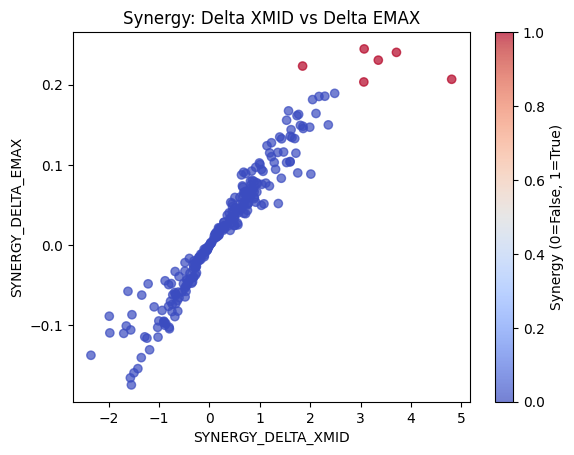

In [18]:
import matplotlib.pyplot as plt

df = detectable_cell_lines[
    ['SYNERGY_DELTA_XMID', 'SYNERGY_DELTA_EMAX', 'Synergy']
].copy()

df['Synergy_num'] = df['Synergy'].astype(int)

plt.figure()

sc = plt.scatter(
    df['SYNERGY_DELTA_XMID'],
    df['SYNERGY_DELTA_EMAX'],
    c=df['Synergy_num'],
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel('SYNERGY_DELTA_XMID')
plt.ylabel('SYNERGY_DELTA_EMAX')
plt.title('Synergy: Delta XMID vs Delta EMAX')

plt.colorbar(sc, label='Synergy (0=False, 1=True)')
plt.show()

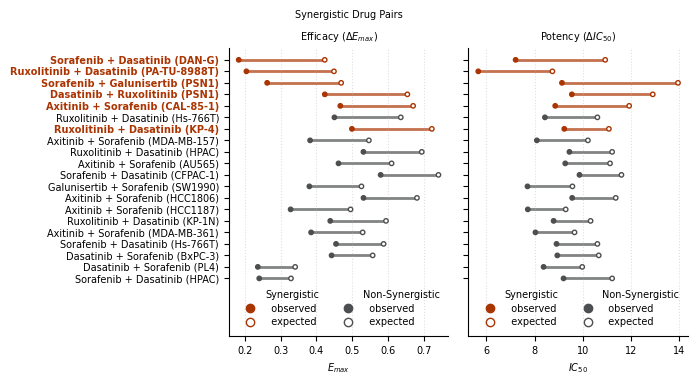

In [19]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def plot_top_synergy(df, N=15, figsize=(7.08, 7.08), fontsize=8,
                     color_non=graycolor,   # color1 — non-synergistic
                     color_syn=tcolor,      # color2 — synergistic
                     dedup_cols=('drug1', 'drug2', 'CELL_LINE_NAME')):
    """Top-N by Borda rank-aggregate of ΔEmax and ΔXMID, shown as
    expected→observed dumbbells, colored by synergy status.
    Duplicate measurements of the same pair+cell line are collapsed to a
    single best representative (synergistic first, then highest Borda)
    BEFORE the top-N cut, so N distinct combinations survive.

    figsize : (w, h) tuple; defaults to (15, height scaled to N).
    fontsize : single value applied to every text element in the figure.
    """
    # Borda: rank each delta (ascending → larger delta = higher rank), sum.
    borda = (df['SYNERGY_DELTA_EMAX'].rank(ascending=True)
             + df['SYNERGY_DELTA_XMID'].rank(ascending=True))   # NaN in either → NaN
    # ---- collapse duplicates: best row per (drug1, drug2, cell line) ----
    work = df.copy()
    work['borda'] = borda
    work['_syn']  = work['Synergy'].astype(bool)
    work = (work.sort_values(['_syn', 'borda'], ascending=[False, False])
                .drop_duplicates(subset=list(dedup_cols), keep='first'))
    # ---- top-N on the deduplicated frame ----
    sel = work.nlargest(N, 'borda').copy()
    sel = sel.sort_values('borda')                              # best at top
    sel['label'] = sel.apply(
        lambda r: f"{r['drug1']} + {r['drug2']} ({r['CELL_LINE_NAME']})", axis=1)

    cmap = {True: color_syn, False: color_non}
    y = list(range(len(sel)))
    cols = [cmap[bool(s)] for s in sel['Synergy']]

    panels = [('Efficacy ($ΔE_{max}$)', 'SYNERGY_OBS_EMAX', 'SYNERGY_EXP_EMAX'),  # obs, exp
              ('Potency ($ΔIC_{50}$)',  'SYNERGY_XMID',      'LIBRARY_XMID')]      # obs, exp
    xlabels = ['$E_{max}$', '$IC_{50}$']

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for ax, (title, obs_c, exp_c), xlab in zip(axes, panels, xlabels):
        for yi, (_, r) in zip(y, sel.iterrows()):
            ax.plot([r[exp_c], r[obs_c]], [yi, yi], color=cmap[bool(r['Synergy'])],
                    lw=2, alpha=.7, zorder=1)
        ax.scatter(sel[obs_c], y, facecolors=cols,    edgecolors=cols, s=10, zorder=3)  # observed
        ax.scatter(sel[exp_c], y, facecolors='white', edgecolors=cols, s=10, zorder=2)  # expected
        ax.set_title(title, fontsize=fontsize)
        ax.set_xlabel(xlab, fontsize=fontsize)
        ax.grid(axis='x', ls=':', alpha=.4)
        ax.tick_params(axis='both', labelsize=fontsize)
        
        ax.set_ylim(-N/4, N) # allow some space at the bottom for the legend
        ax.spines[['right', 'top']].set_visible(False)

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(sel['label'], fontsize=fontsize)

    # make synergistic labels bold
    for label, is_syn in zip(axes[0].get_yticklabels(), sel['Synergy']):
        if is_syn:
            label.set_fontweight('bold')
            label.set_color(tcolor)

    # grouped legend: heading per synergy status, obs/exp markers beneath in that color
    def _h(color, label, hollow=False, head=False):
        if head:                                   # heading row: no marker, just text
            return mlines.Line2D([], [], ls='', marker='', label=label)
        return mlines.Line2D([], [], color=color, ls='', marker='o',
                             mfc='white' if hollow else color, label=label)

    legend_handles = [
        _h(None,      'Synergistic',          head=True),
        _h(color_syn, '  observed'),
        _h(color_syn, '  expected', hollow=True),
        _h(None,      'Non-Synergistic',      head=True),
        _h(color_non, '  observed'),
        _h(color_non, '  expected', hollow=True),
    ]
    for ax in axes:
        ax.legend(handles=legend_handles, loc='lower right',
                  fontsize=fontsize, frameon=False,
                  handletextpad=0.5, labelspacing=0.35, ncol=2)

    fig.suptitle('Synergistic Drug Pairs', y=0.95, fontsize=fontsize)
    fig.tight_layout()
    plt.show()
    return sel, fig
sel, fig = plot_top_synergy(detectable_cell_lines, N=20, figsize=(7.08, 4), fontsize=7,)

#fig.savefig("/home/lnemati/pathway_crosstalk/results/revision/images/synergy_plot.pdf", dpi=300, bbox_inches="tight")
#fig.savefig("/home/lnemati/pathway_crosstalk/results/revision/images/synergy_plot.png", dpi=300, bbox_inches="tight")

# Survival functions

In [20]:
def survival(interactions, df):
    import pandas as pd
    from lifelines import KaplanMeierFitter
    import re   
    
    df = df.copy()
    
    # Extract genes from the interaction string
    genes = list(set(re.split(r'[+&_]', interactions)))

    # Check if there are multiple conditions
    multiple_conditions = len(df['condition'].unique()) > 1

    # Filter and process the DataFrame
    cols = ['OS.time', 'OS', 'condition'] + genes
    df = df[cols]

    # Convert columns to numeric, except for condition
    df.loc[:, [col for col in df.columns if col != 'condition']] = (
        df.loc[:, [col for col in df.columns if col != 'condition']].apply(pd.to_numeric, errors='coerce')
    )
    df = df.dropna()

    # Convert OS time to years
    df['OS.time'] = df['OS.time'] / 365

    high_expression_group = pd.DataFrame()
    low_expression_group = pd.DataFrame()

    if multiple_conditions:
        # If there are multiple conditions, split the patients based on each condition
        for condition in df['condition'].unique():
            condition_df = df[df['condition'] == condition]
            
            # Calculate medians for each gene within the condition
            medians = condition_df[genes].median()
            
            # Identify patients above/below the median for all genes
            high_expression = condition_df[(condition_df[genes] > medians).T.all()]
            low_expression = condition_df[(condition_df[genes] <= medians).T.all()]
            
            # Append to the respective groups
            high_expression_group = pd.concat([high_expression_group, high_expression])
            low_expression_group = pd.concat([low_expression_group, low_expression])
    else:
        # If there is only one condition, split based on the entire dataset
        medians = df[genes].median()
        high_expression_group = df[(df[genes] > medians).T.all()]
        low_expression_group = df[(df[genes] <= medians).T.all()]

    # Remove patients that are in both groups
    common_patients = high_expression_group.index.intersection(low_expression_group)
    high_expression_group = high_expression_group[~high_expression_group.index.isin(common_patients)]
    low_expression_group  = low_expression_group[ ~low_expression_group.index.isin( common_patients)]
        
    # Count number of patients
    n_patients_low = low_expression_group.shape[0]
    n_patients_high = high_expression_group.shape[0]

    # Fit the Kaplan-Meier estimators
    kmf_low = KaplanMeierFitter()
    kmf_high = KaplanMeierFitter()

    kmf_low.fit(
        low_expression_group['OS.time'],
        event_observed=low_expression_group['OS'],
        label="Low Expr."
    )
    kmf_high.fit(
        high_expression_group['OS.time'],
        event_observed=high_expression_group['OS'],
        label="High Expr."
    )

    return {
        'name': interactions,
        'kmf_low': kmf_low,
        'kmf_high': kmf_high,
        'low_expression': low_expression_group.index,
        'high_expression': high_expression_group.index,
    }

In [21]:
def get_genes(string):
    genes = list(re.split(r'[+&_]', string))

    # Remove duplicates while preserving order
    seen = set()
    ordered_genes = []
    for gene in genes:
        if gene not in seen:
            seen.add(gene)
            ordered_genes.append(gene)

    return ordered_genes

# THIS IS THE CORRECT ONE, REPLACE THE OTHERS
def plot_all_3(interaction, tissue, survival_df, axes, xlim=(0, 15), ylim=(0, 1.01), savepath=None,fs=14, smallfs=11, censors_size=1):
        
    df = survival_df.copy()
    #df.index = df.index.str.rsplit(pat='-', n=1, expand=True).get_level_values(0)
    
    interaction_results = survival(interaction, df)
    int1, int2 = interaction.split('&')
    interaction_results1 = survival(int1, df)
    interaction_results2 = survival(int2, df)

    results_list = [interaction_results, interaction_results1, interaction_results2]

    for idx, (ax_box, ax_km) in enumerate(axes):
        result = results_list[idx]
        name = result['name']
        genes = get_genes(name)
        
        # Survival curve data
        pval = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'logrank_pval']
        n_low = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'n_patients_low']
        n_high = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'n_patients_high']

        ax_km.set_xlim(xlim)
        ax_km.set_ylim(ylim)

        ci = False
        if censors_size:
            censors = True
        else:
            censors = False
        result['kmf_low'].plot_survival_function(
            ax=ax_km, color=ncolor, ci_show=ci, show_censors=censors,
            label='Low Expr.'.format(n_low), censor_styles={'ms':censors_size}, 
        )
        result['kmf_high'].plot_survival_function(
            ax=ax_km, color=tcolor, ci_show=ci, show_censors=censors,
            label='High Expr.'.format(n_high), censor_styles={'ms':censors_size},
        )

        ax_km.set_xlabel('Time (Years)', fontsize=fs)
        ax_km.set_ylabel('Survival Prob.', fontsize=fs)
        ax_km.legend(fontsize=smallfs, framealpha=0.5, loc='upper right') 

        ypos = ax_km.get_ylim()[0] + 0.06 * (ax_km.get_ylim()[1] - ax_km.get_ylim()[0])
        xpos = ax_km.get_xlim()[0] + 0.015 * (ax_km.get_xlim()[1] - ax_km.get_xlim()[0])
        text = ax_km.text(xpos, ypos, '$p={:.1e}$'.format(pval), fontsize=smallfs)
        text.set_path_effects([
            path_effects.Stroke(linewidth=8, foreground=(1,1,1,0.5)),
            path_effects.Normal()
        ])

        # Expression boxplot — using survival groups
        df['Group'] = np.nan
        df['Group'] = df['Group'].astype('object')
        df.loc[df.index.isin(result['high_expression']), 'Group'] = 'High Expr.'
        df.loc[df.index.isin(result['low_expression']), 'Group'] = 'Low Expr.'
        # Only keep patients used in survival
        survival_patients = df[df['Group'].notna()]
        violindata = survival_patients.melt(id_vars=['Group'], value_vars=genes)
        violindata['variable'] = pd.Categorical(violindata['variable'], categories=genes, ordered=True)
        
        sns.boxplot(
            data=violindata,
            x='variable',
            y='value',
            hue='Group',
            palette={'High Expr.': tcolor, 'Low Expr.': ncolor},
            order=genes,
            fliersize=0,
            ax=ax_box
        )
        
        #ax_box.set_xlabel('Gene', fontsize=fs)
        ax_box.set_xlabel('')
        ax_box.set_ylabel('log2(0.001 + TPM)', fontsize=fs)
        ax_box.get_legend().remove()
                
        # Format spines and ticks
        for axis in [ax_box, ax_km]:
            axis.tick_params(bottom=True, left=True, axis='both', which='both', direction='out', length=2, width=1, colors='black', labelsize=smallfs)
            axis.spines[['right', 'top']].set_visible(False)
            axis.spines[['left', 'bottom']].set_color('black')

        ax_box.tick_params(axis='x', direction='out', labelsize=smallfs, length=2, width=1, colors='black', rotation=45)
        for label in ax_box.get_xticklabels():
            label.set_ha('right')
        
        add_at_risk_counts(result['kmf_low'], result['kmf_high'], ax=ax_km, ypos=-0.2, rows_to_show=['At risk'], fontsize=smallfs)

    
    # Set all titles
    for idx, (ax_box, ax_km) in enumerate(axes):
        title = tissue.replace('_', ' ').title().replace(' And ', ' & ') + ', '
        if idx == 0:
            title += interaction.replace('&', ' & ').replace('+', ' - ').replace('_', ' - ')
        else:
            title += interaction.split('&')[idx-1].replace('+', ' - ').replace('_', ' - ')
        ax_km.set_title(title, fontsize=fs)

    if savepath is not None:
        plt.savefig(savepath + '.pdf', bbox_inches='tight')
        plt.savefig(savepath + '.png', bbox_inches='tight')


In [22]:
rawdf = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/all_unfiltered.csv')
crosstalkdf = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/all_pairs.csv')

significant = crosstalkdf.query('pval_adj < 0.05')
significant = significant.query('not ((hr - se) < 1 and 1 < (hr + se))')

better = significant.copy()
better = better.query('hr_lfc_best > 0.')
better = better.query('c_diff_best > 0.')
better = better.query('(logrank_pval < logrank_pval1) and (logrank_pval < logrank_pval2)')

cliques = better.query('tissue != "Pan_Cancer" and motif in ["3_clique", "4_clique"]')

better.head(3)

,interaction,tissue,hr,hr1,hr2,concordance_index,concordance_index1,concordance_index2,logrank_pval,logrank_pval1,...,min_patients,min_patients1,min_patients2,log2_hr,log2_hr1,log2_hr2,pval_adj,hr_lfc_best,c_diff_best,motif
0,ADA+ADORA2B&FBN1+ITGA5_ITGB1,Pan_Cancer,2.473422,1.449832,1.453431,0.525176,0.520904,0.522021,1.996489e-290,2.866094e-192,...,46629,112035,101772,1.306508,0.535886,0.539462,1.599185e-284,0.767046,0.003155,4_path
1,COL6A3+ITGA10_ITGB1&ADA+ADORA2B,Pan_Cancer,2.690729,1.434415,1.449832,0.522922,0.516268,0.520904,2.855622e-255,2.507191e-171,...,29337,76494,112035,1.427997,0.520463,0.535886,1.143675e-249,0.892112,0.002018,4_no_crosstalk
2,FN1+ITGA11_ITGB1&ADA+ADORA2B,Pan_Cancer,2.452652,1.395628,1.449832,0.526302,0.520509,0.520904,1.348607e-251,3.625836e-201,...,37092,93621,112035,1.294343,0.480914,0.535886,3.600776e-246,0.758457,0.005398,4_no_crosstalk


# Survival - Targetable Clique

In [23]:
survival_breast = pd.read_csv('/home/lnemati/pathway_crosstalk/data/survival_data/tissues/breast.csv', index_col=0)

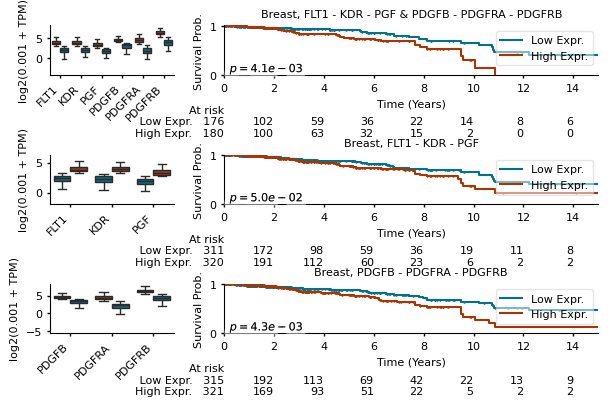

In [24]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fs = 8
smallfs = 8

fig = plt.figure(figsize=(7.08, 4))
gs = GridSpec(3, 2, width_ratios=[1, 3], height_ratios=[1, 1, 1], figure=fig)

axes = []
for row in range(3):
    ax_box = fig.add_subplot(gs[row, 0])  # Boxplot on left
    ax_km = fig.add_subplot(gs[row, 1])   # KM curve on right
    axes.append((ax_box, ax_km))

fig.subplots_adjust(hspace=1.6, wspace=0.2)

plot_all_3(
    'FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB',
    'Breast',
    survival_breast,
    axes,
    fs=fs,
    smallfs=smallfs,
    #savepath="/home/lnemati/pathway_crosstalk/results/figures/survival/targetable_clique"
)


/var/tmp/pbs.436024.pbs01/ipykernel_293472/3431849214.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'High Expr.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.index.isin(res['high_expression']), 'Group'] = 'High Expr.'


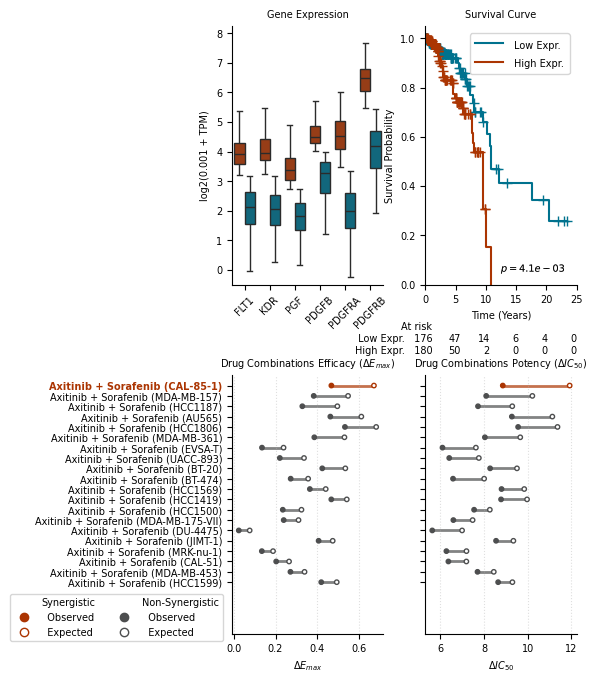

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.lines as mlines
import re
from lifelines.plotting import add_at_risk_counts

# ----------------------------
# UNIFIED FONT SIZE
# ----------------------------
fs = 7
censors_size = 7

# ----------------------------
# INPUTS
# ----------------------------
interaction = 'FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB'
tissue = 'Breast'
survival_df = survival_breast

# ----------------------------
# Survival computation
# ----------------------------
res = survival(interaction, survival_df.copy())
genes = get_genes(res['name'])

df = survival_df.copy()
df['Group'] = np.nan
df.loc[df.index.isin(res['high_expression']), 'Group'] = 'High Expr.'
df.loc[df.index.isin(res['low_expression']),  'Group'] = 'Low Expr.'
df = df[df['Group'].notna()]

viol = df.melt(id_vars=['Group'], value_vars=genes)

try:
    pval = rawdf.set_index(['interaction', 'tissue']).loc[(res['name'], tissue), 'logrank_pval']
except:
    pval = np.nan


# ----------------------------
# SYNERGY (NO LEGEND INSIDE FUNCTION)
# ----------------------------
def plot_top_synergy(df, N=15, figsize=(7.08, 7.08),
                     fontsize=fs,
                     color_non=graycolor,
                     color_syn=tcolor,
                     dedup_cols=('drug1', 'drug2', 'CELL_LINE_NAME'),
                     axes=None):

    borda = (df['SYNERGY_DELTA_EMAX'].rank(ascending=True)
             + df['SYNERGY_DELTA_XMID'].rank(ascending=True))

    work = df.copy()
    work['borda'] = borda
    work['_syn'] = work['Synergy'].astype(bool)

    work = (work.sort_values(['_syn', 'borda'], ascending=[False, False])
                .drop_duplicates(subset=list(dedup_cols), keep='first'))

    sel = work.nlargest(N, 'borda').copy()
    sel = sel.sort_values('borda')

    sel['label'] = sel.apply(
        lambda r: f"{r['drug1']} + {r['drug2']} ({r['CELL_LINE_NAME']})", axis=1
    )

    cmap = {True: color_syn, False: color_non}
    y = np.arange(len(sel))
    cols = [cmap[bool(s)] for s in sel['Synergy']]

    panels = [
        ('Drug Combinations Efficacy ($ΔE_{max}$)', 'SYNERGY_OBS_EMAX', 'SYNERGY_EXP_EMAX'),
        ('Drug Combinations Potency ($ΔIC_{50}$)',  'SYNERGY_XMID',     'LIBRARY_XMID')
    ]

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    else:
        fig = axes[0].figure
        axes[1].sharey(axes[0])

    for ax, (title_, obs_c, exp_c) in zip(axes, panels):

        for yi, (_, r) in zip(y, sel.iterrows()):
            col = cmap[bool(r['Synergy'])]
            ax.plot([r[exp_c], r[obs_c]], [yi, yi],
                    color=col, lw=2, alpha=0.7, zorder=1)

        ax.scatter(sel[obs_c], y,
                   facecolors=cols,
                   edgecolors=cols,
                   s=10, zorder=3)

        ax.scatter(sel[exp_c], y,
                   facecolors='white',
                   edgecolors=cols,
                   s=10, zorder=2)

        ax.set_title(title_, fontsize=fs)
        ax.set_xlabel(title_.split('(')[-1].replace(')', ''), fontsize=fs)

        ax.grid(axis='x', ls=':', alpha=0.4)
        ax.tick_params(axis='both', labelsize=fs, direction='out')

        ax.set_ylim(-len(sel)/4, len(sel))
        ax.spines[['right', 'top']].set_visible(False)

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(sel['label'], fontsize=fs)

    for label, is_syn in zip(axes[0].get_yticklabels(), sel['Synergy']):
        if is_syn:
            label.set_fontweight('bold')
            label.set_color(tcolor)

    axes[1].tick_params(axis='y', labelleft=False)

    return sel, fig


# ----------------------------
# FIGURE
# ----------------------------
fig = plt.figure(figsize=(7.08, 8))

axd = fig.subplot_mosaic(
    """
    XAB
    YCD
    """
)

# ----------------------------
# A: BOX PLOT
# ----------------------------
sns.boxplot(
    data=viol,
    x='variable',
    y='value',
    hue='Group',
    palette={'High Expr.': tcolor, 'Low Expr.': ncolor},
    fliersize=0,
    ax=axd['A']
)

axd['A'].set_title("Gene Expression", fontsize=fs)
axd['A'].set_xlabel("")
axd['A'].set_ylabel("log2(0.001 + TPM)", fontsize=fs)
axd['A'].tick_params(axis='x', rotation=45, labelsize=fs, direction='out')
axd['A'].tick_params(axis='y', labelsize=fs)
axd['A'].legend_.remove()
axd['A'].spines[['right', 'top']].set_visible(False)
axd['A'].set_ylim(bottom=-0.5)

# ----------------------------
# B: KM CURVE + AT RISK
# ----------------------------
km_low  = res['kmf_low']
km_high = res['kmf_high']

km_low.plot_survival_function(ax=axd['B'], color=ncolor, ci_show=False, show_censors=True, censor_styles={'ms':censors_size})
km_high.plot_survival_function(ax=axd['B'], color=tcolor, ci_show=False, show_censors=True, censor_styles={'ms':censors_size})

max_time = axd['B'].get_xlim()[1]
xticks = np.arange(0, np.ceil(max_time)+1, 5)

axd['B'].set_xticks(xticks)

add_at_risk_counts(
    km_low,
    km_high,
    ax=axd['B'],
    rows_to_show=['At risk'],
    xticks=xticks,
    fontsize=fs,
    ypos=-0.3
)

axd['B'].set_title("Survival Curve", fontsize=fs)
axd['B'].set_xlabel("Time (Years)", fontsize=fs)
axd['B'].set_ylabel("Survival Probability", fontsize=fs)
axd['B'].tick_params(axis='both', labelsize=fs, direction='out')
axd['B'].spines[['right', 'top']].set_visible(False)
axd['B'].set_ylim(bottom=0)
axd['B'].set_xlim(left=0)

if not np.isnan(pval):
    text = axd['B'].text(
        0.5, 0.05,
        f"$p={pval:.1e}$",
        transform=axd['B'].transAxes,
        fontsize=fs
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=8, foreground=(1,1,1,0.5)),
        path_effects.Normal()
    ])

# enforce consistent legend fontsize for ax B
leg = axd['B'].get_legend()
if leg is not None:
    for text in leg.get_texts():
        text.set_fontsize(fs)
    
# ----------------------------
axd['B'].set_title(f"Survival Curve", fontsize=fs)

# ----------------------------
# C & D: SYNERGY
# ----------------------------
sel, _ = plot_top_synergy(
    detectable_cell_lines.query('drug1 in ["Axitinib", "Sorafenib"] and drug2 in ["Axitinib", "Sorafenib"]'),
    N=20,
    fontsize=fs,
    axes=(axd['C'], axd['D'])
)

# ----------------------------
# FIGURE-LEVEL LEGEND (FIG COORDINATES)
# ----------------------------
def _h(color, label, hollow=False, head=False):
    if head:
        return mlines.Line2D([], [], ls='', marker='', label=label)
    return mlines.Line2D([], [], color=color, ls='', marker='o',
                         mfc='white' if hollow else color, label=label)

legend_handles = [
    _h(None,      'Synergistic',     head=True),
    _h(tcolor,    '  Observed'),
    _h(tcolor,    '  Expected', hollow=True),
    _h(None,      'Non-Synergistic', head=True),
    _h(graycolor, '  Observed'),
    _h(graycolor, '  Expected', hollow=True),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.33, 0.165),
    frameon=True,
    fontsize=fs,
    ncol=2,
)

# ----------------------------
# SPACING
# ----------------------------
plt.subplots_adjust(
    left=0.22,
    right=0.98,
    top=0.94,
    bottom=0.18,
    wspace=0.28,
    hspace=0.35
)

axd['X'].axis('off')
axd['Y'].axis('off')

fig.savefig("/home/lnemati/pathway_crosstalk/results/revision/images/axitinib_sorafenib_synergy_and_survival_plot.pdf", dpi=300, bbox_inches="tight")
fig.savefig("/home/lnemati/pathway_crosstalk/results/revision/images/axitinib_sorafenib_synergy_and_survival_plot.svg", dpi=300, bbox_inches="tight")
fig.savefig("/home/lnemati/pathway_crosstalk/results/revision/images/axitinib_sorafenib_synergy_and_survival_plot.png", dpi=300, bbox_inches="tight")

plt.show()